# Load Data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
from utils.data_loader import load_parquet, load_csv

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())


✅ Successfully loaded data with shape: (3157920, 2)
                 time  orbital_decay
0 2023-01-01 00:00:00        16.6730
1 2023-01-01 00:00:20        16.6730
2 2023-01-01 00:00:40        16.6735
3 2023-01-01 00:01:00        16.6740
4 2023-01-01 00:01:20        16.6740


# 1. Select a subset

In [2]:
from utils.plot_loader import create_subset
# =========================== Input ===================================
start_date = '2024-04-26 00:00:00'
end_date = '2024-05-01 00:00:00'
# =====================================================================

subset = create_subset(GFOC_data, start_date, end_date)
time = subset['time'].values
# make 'time' the index
subset.set_index('time', inplace=True)

# 2. Prepare Data

In [ ]:
def make_lags(ts, lags, lead_time=1, step_size=1):
    return pd.concat(
        {
            f'y_lag_{i}': ts.shift(i)
            for i in range(lead_time, lags * step_size + lead_time, step_size)
        },
        axis=1)


# Four weeks of lag features
y = subset[['orbital_decay']].copy()
X = make_lags(y, lags=10, step_size=20).fillna(0.0)


def make_multistep_target(ts, steps):
    return pd.concat(
        {f'y_step_{i + 1}': ts.shift(-i)
         for i in range(steps)},
        axis=1)


# n hour forecast (20 second intervals)
n = 1
y = make_multistep_target(y, steps=n * 3 * 60).dropna()

# Shifting has created indexes that don't match. Only keep times for
# which we have both targets and features.
y, X = y.align(X, join='inner', axis=0)

## Normalise

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Train-test split (chronologically)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Fit scalers only on training data
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

# Transform data
X_train_scaled = scaler_X.transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# 3. Multioutput Model

In [11]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

# model = LinearRegression()
model = MultiOutputRegressor(XGBRegressor())
model.fit(X_train_scaled, y_train_scaled)

# Predictions
y_fit_scaled = model.predict(X_train_scaled)
y_pred_scaled = model.predict(X_test_scaled)

# Inverse transform to original units
y_fit = pd.DataFrame(scaler_y.inverse_transform(y_fit_scaled),
                     index=X_train.index, columns=y.columns)
y_pred = pd.DataFrame(scaler_y.inverse_transform(y_pred_scaled),
                      index=X_test.index, columns=y.columns)

Save model

In [12]:
# model_10_20 = model

## Results

In [13]:
from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error

simplefilter("ignore")

# Set Matplotlib defaults
plt.style.use("default")
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)
%config InlineBackend.figure_format = 'retina'


def plot_multistep(y, every=1, ax=None, palette_kwargs=None):
    palette_kwargs_ = dict(palette='husl', n_colors=16, desat=None)
    if palette_kwargs is not None:
        palette_kwargs_.update(palette_kwargs)
    palette = sns.color_palette(**palette_kwargs_)
    if ax is None:
        fig, ax = plt.subplots()
    ax.set_prop_cycle(plt.cycler('color', palette))
    for date, preds in y[::every].iterrows():
        preds.index = pd.period_range(start=date, periods=len(preds), freq='20S')
        preds.plot(ax=ax)
    return ax

## Results

In [14]:
train_rmse = mean_squared_error(y_train, y_fit)
test_rmse = mean_squared_error(y_test, y_pred)
print((f"Train RMSE: {train_rmse:.2f}\n" f"Test RMSE: {test_rmse:.2f}"))

Train RMSE: 0.00
Test RMSE: 161.82


## Plot

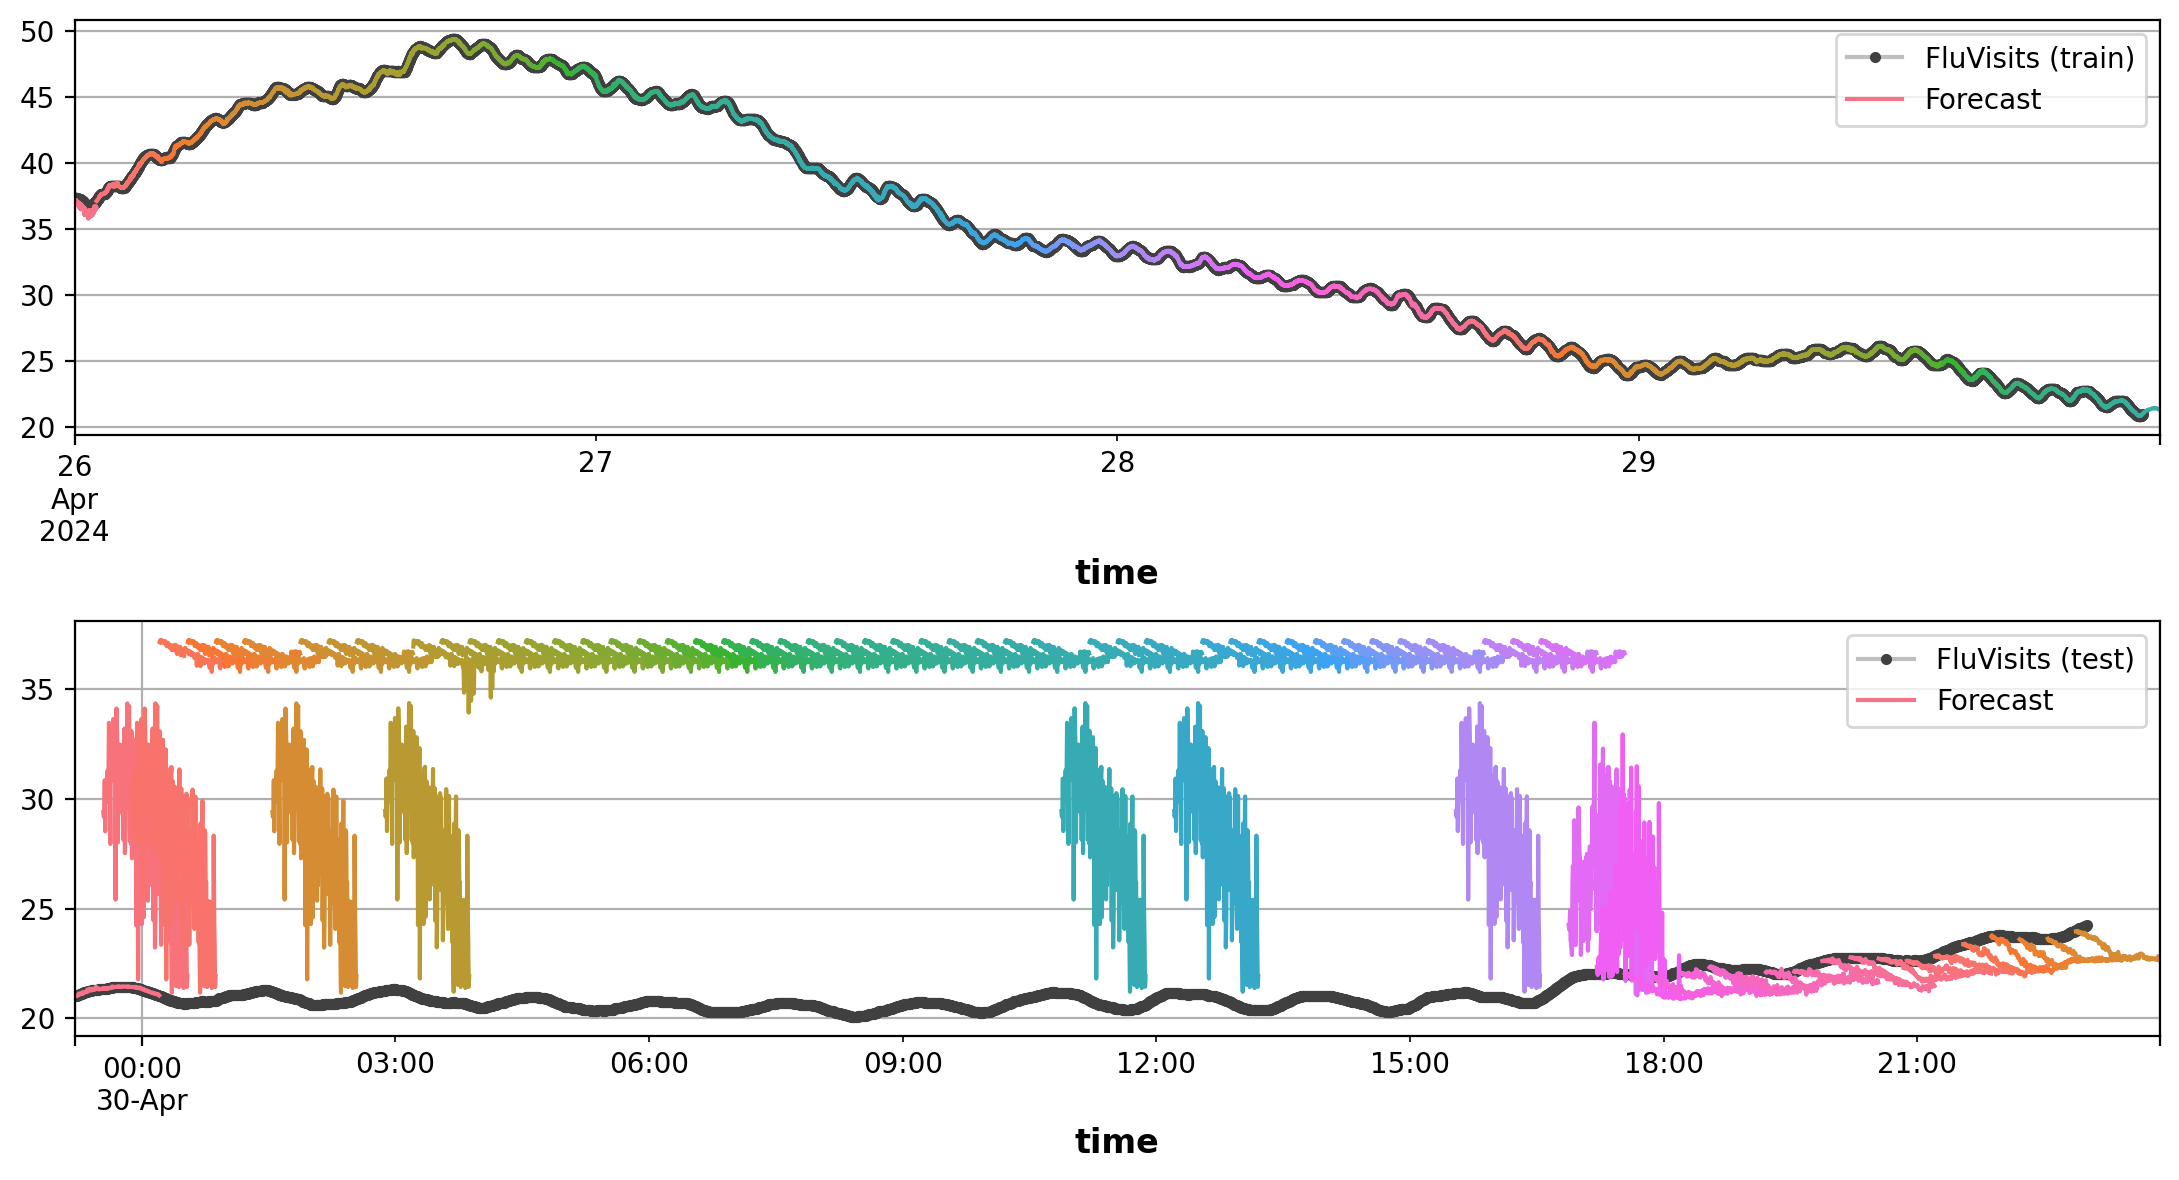

In [ ]:

palette = dict(palette='husl', n_colors=64)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
ax1 = y_train['y_step_1'].plot(**plot_params, ax=ax1)
ax1 = plot_multistep(y_fit, every=180, ax=ax1, palette_kwargs=palette)
_ = ax1.legend(['Orbital Decay (train)', 'Forecast'])
ax1.grid(True)

ax2 = y_test['y_step_1'].plot(**plot_params, ax=ax2)
ax2 = plot_multistep(y_pred, every=60, ax=ax2, palette_kwargs=palette)
_ = ax2.legend(['Orbital Decay (test)', 'Forecast'])
ax2.grid(True)

## Findings

- The Predictions failed completely when the test data was not in the range of the training data (orbital decay above ~18 m/day)
- prediction captured the seasonal trends (orbital period of GRACE) at least sometimes.
- I noticed that prediction got worse and worse in the future. The first 1-3 hours were ok (ish), but afterwards it got worse. Funny enought, this effect increased if I added more lags.
- adding more data also did not improve it

## Next Steps
- use difference insted of raw values to fix problem with ranges

y_diff = y.diff().fillna(0.0)

- a

## Compare to real Data

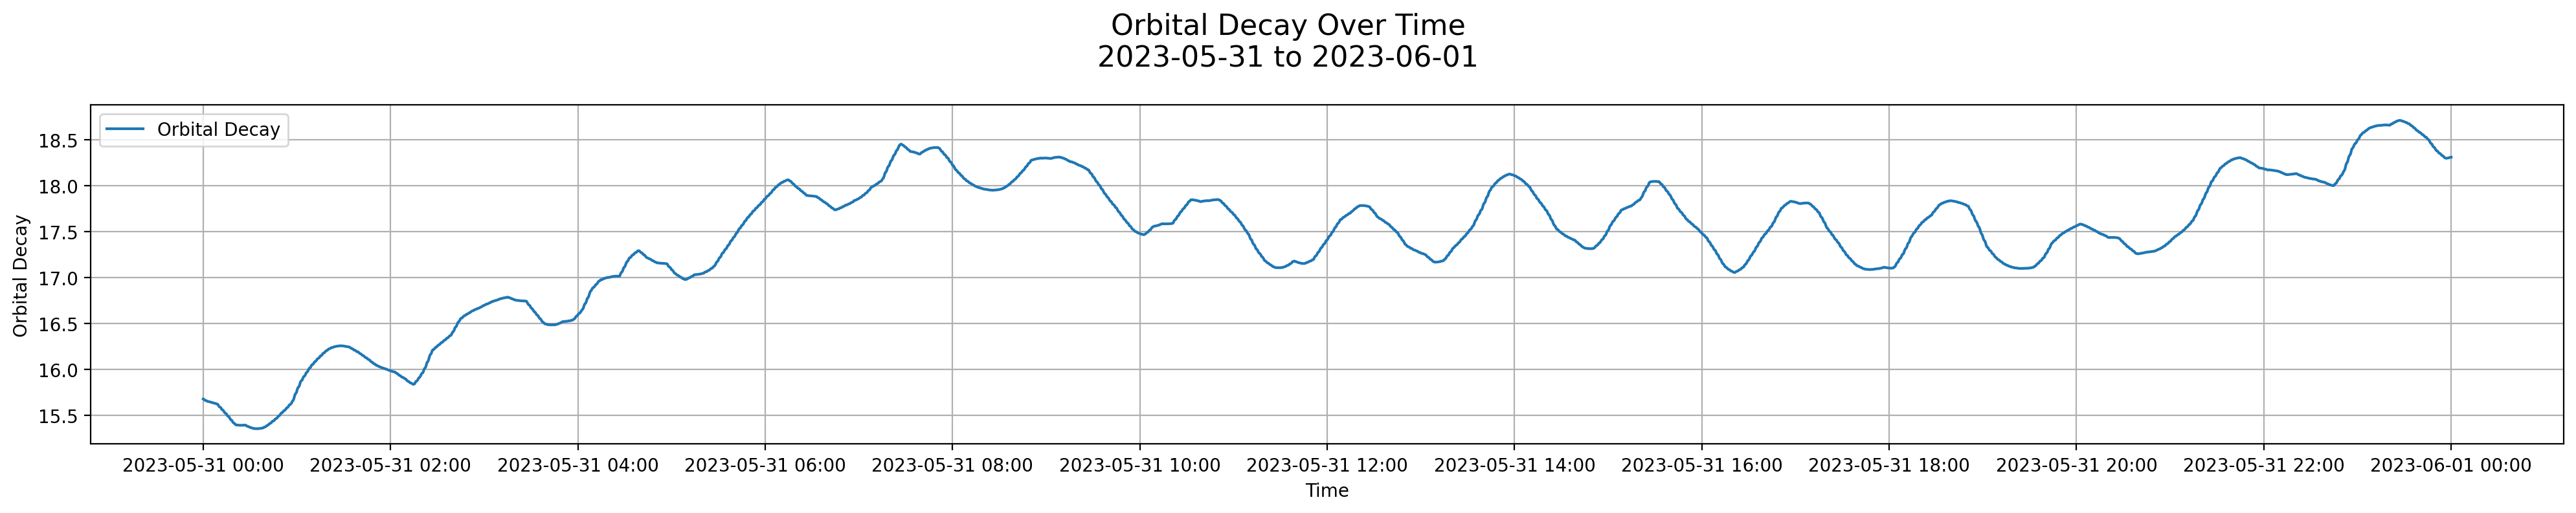

In [16]:
from utils.plot_loader import plot_orbital_decay

# =========================== Input ===================================
start_date = '2023-05-31 00:00:00'
end_date = '2023-06-01 00:00:00'

# Add an option for monthly, daily, or hourly ticks
tick_interval = 'hourly'  # Change to 'monthly', 'daily', or 'hourly'
tick_step = 2  # Step for the ticks (e.g., every month =1, every 2 months = 2, etc)

Flags = False

plot_orbital_decay(GFOC_data, None, start_date, end_date, tick_interval, tick_step, FLAGS=Flags, Lombscargle=False, figsize=(20, 4))

test = create_subset(GFOC_data, '2023-05-31 06:00:00', '2023-05-31 07:00:00')